# Bankruptcy Prediction — Data Cleaning & Feature Engineering

Handle missing values, engineer features, encode categoricals, save cleaned dataset.

## 1. Imports & Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from utils import load_data, preprocess_data, create_features

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = load_data()
print('Raw shape:', df.shape)
df.head()

Raw shape: (6819, 95)


,Bankrupt,ROA_C_Before_Interest_Depreciation,ROA_A_Before_Interest_After_Tax,ROA_B_Before_Interest_Depreciation_After_Tax,Operating_Gross_Margin,Realized_Sales_Gross_Margin,Operating_Profit_Rate,PreTax_Net_Interest_Rate,AfterTax_Net_Interest_Rate,NonIndustry_Income_Expenditure_Revenue,Continuous_Interest_Rate_After_Tax,Operating_Expense_Rate,R&D_Expense_Rate,Cash_Flow_Rate,InterestBearing_Debt_Interest_Rate,Tax_Rate_A,Net_Value_Per_Share_B,Net_Value_Per_Share_A,Net_Value_Per_Share_C,Persistent_EPS_Last_4_Seasons,Cash_Flow_Per_Share,Revenue_Per_Share,Operating_Profit_Per_Share,Net_Profit_Before_Tax_Per_Share,Realized_Sales_Gross_Profit_Growth_Rate,Operating_Profit_Growth_Rate,AfterTax_Net_Profit_Growth_Rate,Regular_Net_Profit_Growth_Rate,Continuous_Net_Profit_Growth_Rate,Total_Asset_Growth_Rate,Net_Value_Growth_Rate,Total_Asset_Return_Growth_Rate,Cash_Reinvestment_Percent,Current_Ratio,Quick_Ratio,Interest_Expense_Ratio,Total_Debt_to_Net_Worth,Debt_Ratio_Percent,Net_Worth_to_Assets,LongTerm_Fund_Suitability_Ratio_A,Borrowing_Dependency,Contingent_Liabilities_to_Net_Worth,Operating_Profit_to_PaidIn_Capital,Net_Profit_Before_Tax_to_PaidIn_Capital,Inventory_Accounts_Receivable_to_Net_Value,Total_Asset_Turnover,Accounts_Receivable_Turnover,Average_Collection_Days,Inventory_Turnover_Rate,Fixed_Assets_Turnover_Frequency,Net_Worth_Turnover_Rate,Revenue_Per_Person,Operating_Profit_Per_Person,Allocation_Rate_Per_Person,Working_Capital_to_Total_Assets,Quick_Assets_to_Total_Assets,Current_Assets_to_Total_Assets,Cash_to_Total_Assets,Quick_Assets_to_Current_Liability,Cash_to_Current_Liability,Current_Liability_to_Assets,Operating_Funds_to_Liability,Inventory_to_Working_Capital,Inventory_to_Current_Liability,Current_Liabilities_to_Liability,Working_Capital_to_Equity,Current_Liabilities_to_Equity,LongTerm_Liability_to_Current_Assets,Retained_Earnings_to_Total_Assets,Total_Income_to_Total_Expense,Total_Expense_to_Assets,Current_Asset_Turnover_Rate,Quick_Asset_Turnover_Rate,Working_Capital_Turnover_Rate,Cash_Turnover_Rate,Cash_Flow_to_Sales,Fixed_Assets_to_Assets,Current_Liability_to_Liability,Current_Liability_to_Equity,Equity_to_LongTerm_Liability,Cash_Flow_to_Total_Assets,Cash_Flow_to_Liability,CFO_to_Assets,Cash_Flow_to_Equity,Current_Liability_to_Current_Assets,Liability_Assets_Flag,Net_Income_to_Total_Assets,Total_Assets_to_GNP_Price,NoCredit_Interval,Gross_Profit_to_Sales,Net_Income_to_Stockholders_Equity,Liability_to_Equity,DFL,Interest_Coverage_Ratio,Equity_to_Liability
0,0,0.571832,0.642390,0.634670,0.626169,0.626169,0.999232,0.797749,0.809653,0.303602,0.781929,2.592570e-04,2.884653e-04,0.477800,0.000602,0.001518,0.216341,0.216341,0.216341,0.258013,0.332178,0.026846,0.129143,0.205694,0.022095,0.848031,0.689420,0.689420,0.217595,8.550000e+09,0.000558,0.264055,0.380910,0.014799,0.013536,0.630630,0.001675,0.045681,0.954319,0.006615,0.369637,0.005366,0.128096,0.203544,0.396278,0.115442,0.001049,0.006032,2.520253e-04,0.000401,0.024516,0.026221,0.415628,0.007991,0.814134,0.379162,0.389149,0.214547,0.013949,0.022700,0.049786,0.389006,0.277031,0.002548,0.980840,0.735034,0.327735,0.000000e+00,0.953847,0.002552,0.031021,1.458139e-04,1.477731e-04,0.593979,2.261115e-04,0.671535,0.126175,0.980840,0.327735,0.110933,0.596608,0.435000,0.640667,0.309438,0.019815,0,0.854406,0.007801,0.623980,0.626165,0.843256,0.275994,0.026797,0.565185,0.083956
1,0,0.494613,0.549771,0.543445,0.602091,0.602091,0.998986,0.797405,0.809328,0.303516,0.781588,1.194525e-04,5.600000e+09,0.459113,0.000819,0.082397,0.173149,0.173149,0.173149,0.219911,0.312230,0.052589,0.101376,0.174588,0.022419,0.848212,0.689860,0.689860,0.217646,7.150000e+09,0.000459,0.264625,0.365057,0.009129,0.005370,0.631718,0.008838,0.145539,0.854461,0.005988,0.372533,0.005366,0.101340,0.173652,0.410604,0.241379,0.000903,0.007003,1.110134e-04,0.001036,0.059677,0.024908,0.394021,0.003047,0.819905,0.472840,0.742088,0.083393,0.005628,0.002915,0.151688,0.333883,0.277546,0.009394,0.991961,0.737549,0.334045,3.490

## 2. Handle Missing / Invalid Values

In [3]:
# No missing values, but the dataset has heavy outliers in financial ratios.
print('Missing values:', df.isnull().sum().sum())
from utils import cap_outliers
df_clean = cap_outliers(df, lower=0.005, upper=0.995)
print('Outlier capping applied at 0.5%/99.5% quantiles')

Missing values: 0
Outlier capping applied at 0.5%/99.5% quantiles


## 3. Imputation

In [4]:
print('NaN count:', df_clean.isnull().sum().sum())
df_imputed = df_clean.copy()

NaN count: 0


## 4. Distribution Comparison Before vs After Imputation

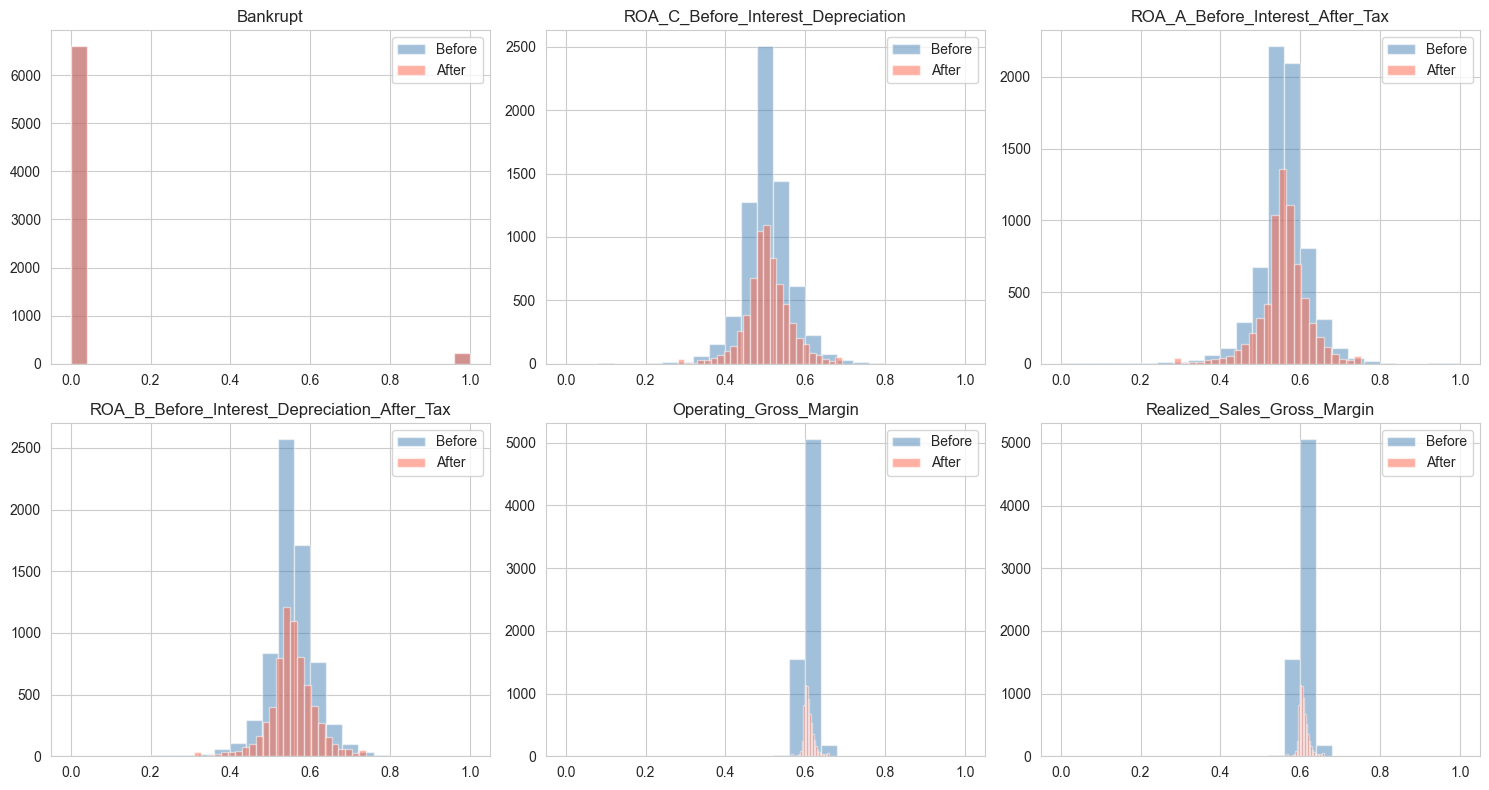

In [5]:
numeric_cols_for_plot = df.select_dtypes(include=[np.number]).columns[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols_for_plot):
    if i >= 6: break
    if col in df.columns:
        axes[i].hist(df[col].dropna(), bins=25, alpha=0.5, label='Before', color='steelblue')
    if col in df_imputed.columns:
        axes[i].hist(df_imputed[col], bins=25, alpha=0.5, label='After', color='tomato')
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

## 5. Feature Engineering

In [6]:
df_feat = create_features(df_imputed)
print('After feature engineering:', df_feat.shape)
df_feat.head()

After feature engineering: (6819, 98)


,Bankrupt,ROA_C_Before_Interest_Depreciation,ROA_A_Before_Interest_After_Tax,ROA_B_Before_Interest_Depreciation_After_Tax,Operating_Gross_Margin,Realized_Sales_Gross_Margin,Operating_Profit_Rate,PreTax_Net_Interest_Rate,AfterTax_Net_Interest_Rate,NonIndustry_Income_Expenditure_Revenue,Continuous_Interest_Rate_After_Tax,Operating_Expense_Rate,R&D_Expense_Rate,Cash_Flow_Rate,InterestBearing_Debt_Interest_Rate,Tax_Rate_A,Net_Value_Per_Share_B,Net_Value_Per_Share_A,Net_Value_Per_Share_C,Persistent_EPS_Last_4_Seasons,Cash_Flow_Per_Share,Revenue_Per_Share,Operating_Profit_Per_Share,Net_Profit_Before_Tax_Per_Share,Realized_Sales_Gross_Profit_Growth_Rate,Operating_Profit_Growth_Rate,AfterTax_Net_Profit_Growth_Rate,Regular_Net_Profit_Growth_Rate,Continuous_Net_Profit_Growth_Rate,Total_Asset_Growth_Rate,Net_Value_Growth_Rate,Total_Asset_Return_Growth_Rate,Cash_Reinvestment_Percent,Current_Ratio,Quick_Ratio,Interest_Expense_Ratio,Total_Debt_to_Net_Worth,Debt_Ratio_Percent,Net_Worth_to_Assets,LongTerm_Fund_Suitability_Ratio_A,Borrowing_Dependency,Contingent_Liabilities_to_Net_Worth,Operating_Profit_to_PaidIn_Capital,Net_Profit_Before_Tax_to_PaidIn_Capital,Inventory_Accounts_Receivable_to_Net_Value,Total_Asset_Turnover,Accounts_Receivable_Turnover,Average_Collection_Days,Inventory_Turnover_Rate,Fixed_Assets_Turnover_Frequency,Net_Worth_Turnover_Rate,Revenue_Per_Person,Operating_Profit_Per_Person,Allocation_Rate_Per_Person,Working_Capital_to_Total_Assets,Quick_Assets_to_Total_Assets,Current_Assets_to_Total_Assets,Cash_to_Total_Assets,Quick_Assets_to_Current_Liability,Cash_to_Current_Liability,Current_Liability_to_Assets,Operating_Funds_to_Liability,Inventory_to_Working_Capital,Inventory_to_Current_Liability,Current_Liabilities_to_Liability,Working_Capital_to_Equity,Current_Liabilities_to_Equity,LongTerm_Liability_to_Current_Assets,Retained_Earnings_to_Total_Assets,Total_Income_to_Total_Expense,Total_Expense_to_Assets,Current_Asset_Turnover_Rate,Quick_Asset_Turnover_Rate,Working_Capital_Turnover_Rate,Cash_Turnover_Rate,Cash_Flow_to_Sales,Fixed_Assets_to_Assets,Current_Liability_to_Liability,Current_Liability_to_Equity,Equity_to_LongTerm_Liability,Cash_Flow_to_Total_Assets,Cash_Flow_to_Liability,CFO_to_Assets,Cash_Flow_to_Equity,Current_Liability_to_Current_Assets,Liability_Assets_Flag,Net_Income_to_Total_Assets,Total_Assets_to_GNP_Price,NoCredit_Interval,Gross_Profit_to_Sales,Net_Income_to_Stockholders_Equity,Liability_to_Equity,DFL,Interest_Coverage_Ratio,Equity_to_Liability,AvgProfitability,AvgLeverage,AvgLiquidity
0,0,0.571832,0.642390,0.634670,0.626169,0.626169,0.999232,0.797749,0.809653,0.303602,0.781929,2.592570e-04,2.884653e-04,0.477800,0.000602,0.001518,0.216341,0.216341,0.216341,0.258013,0.332178,0.026846,0.129143,0.205694,0.022095,0.848031,0.689420,0.689420,0.217595,8.550000e+09,0.000558,0.264055,0.380910,0.014799,0.013536,0.630630,0.001675,0.045681,0.954319,0.006615,0.369637,0.005366,0.128096,0.203544,0.396278,0.115442,0.001049,0.006032,2.520253e-04,0.000401,0.024516,0.026221,0.415628,0.007991,0.814134,0.379162,0.389149,0.214547,0.013949,0.022700,0.049786,0.389006,0.277031,0.002548,0.980840,0.735034,0.327735,0.000000e+00,0.953847,0.002552,0.031021,1.458139e-04,1.477731e-04,0.593979,2.261115e-04,0.671535,0.126175,0.980840,0.327735,0.110933,0.596608,0.435000,0.640667,0.309438,0.019815,0,0.854406,0.007801,0.623980,0.626165,0.843256,0.275994,0.026797,0.565185,0.083956,0.709311,2.163525e-01,2.891064e-01
1,0,0.494613,0.549771,0.543445,0.602091,0.602091,0.998986,0.797405,0.809328,0.303516,0.781588,1.194525e-04,5.600000e+09,0.459113,0.000819,0.082397,0.173149,0.173149,0.173149,0.219911,0.312230,0.052589,0.101376,0.174588,0.022419,0.848212,0.689860,0.689860,0.217646,7.150000e+09,0.000459,0.264625,0.365057,0.009129,0.005370,0.631718,0.008838,0.145539,0.854461,0.005988,0.372533,0.005366,0.101340,0.173652,0.410604,0.241379,0.000903,0.007003,1.110134e-04,0.001036,0.059677,0.024908,0.394021,0.003047,0.819905,0.472840,0.742088,0.083393,0.005628,

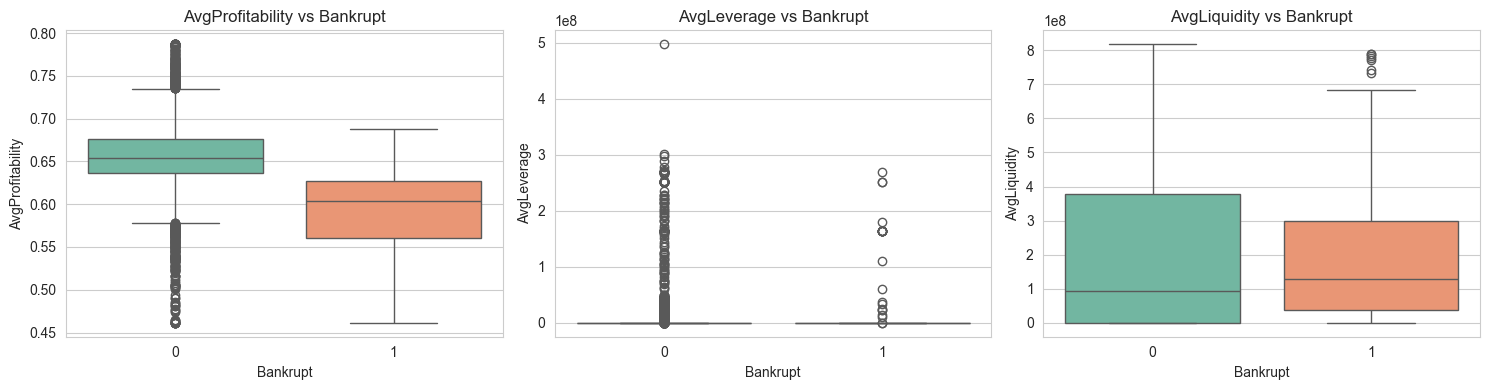

In [7]:
agg_features = [c for c in ['AvgProfitability', 'AvgLeverage', 'AvgLiquidity'] if c in df_feat.columns]
if agg_features:
    fig, axes = plt.subplots(1, len(agg_features), figsize=(5*len(agg_features), 4))
    if len(agg_features) == 1: axes = [axes]
    for ax, col in zip(axes, agg_features):
        sns.boxplot(x='Bankrupt', y=col, data=df_feat, ax=ax, palette='Set2')
        ax.set_title(f'{col} vs Bankrupt')
    plt.tight_layout(); plt.show()

## 6. Encode Categorical Features

In [8]:
# All features already numeric — no encoding needed
df_encoded = df_feat.copy()
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print('Final shape:', df_encoded.shape)

Final shape: (6819, 98)


## 7. Verify & Save Cleaned Dataset

In [9]:
print('Missing values:', df_encoded.isnull().sum().sum())
print('Final shape:', df_encoded.shape)
df_encoded.to_csv('data/bankruptcy_cleaned.csv', index=False)
print('Saved -> data/bankruptcy_cleaned.csv')
df_encoded.head()

Missing values: 0
Final shape: (6819, 98)


Saved -> data/bankruptcy_cleaned.csv


,Bankrupt,ROA_C_Before_Interest_Depreciation,ROA_A_Before_Interest_After_Tax,ROA_B_Before_Interest_Depreciation_After_Tax,Operating_Gross_Margin,Realized_Sales_Gross_Margin,Operating_Profit_Rate,PreTax_Net_Interest_Rate,AfterTax_Net_Interest_Rate,NonIndustry_Income_Expenditure_Revenue,Continuous_Interest_Rate_After_Tax,Operating_Expense_Rate,R&D_Expense_Rate,Cash_Flow_Rate,InterestBearing_Debt_Interest_Rate,Tax_Rate_A,Net_Value_Per_Share_B,Net_Value_Per_Share_A,Net_Value_Per_Share_C,Persistent_EPS_Last_4_Seasons,Cash_Flow_Per_Share,Revenue_Per_Share,Operating_Profit_Per_Share,Net_Profit_Before_Tax_Per_Share,Realized_Sales_Gross_Profit_Growth_Rate,Operating_Profit_Growth_Rate,AfterTax_Net_Profit_Growth_Rate,Regular_Net_Profit_Growth_Rate,Continuous_Net_Profit_Growth_Rate,Total_Asset_Growth_Rate,Net_Value_Growth_Rate,Total_Asset_Return_Growth_Rate,Cash_Reinvestment_Percent,Current_Ratio,Quick_Ratio,Interest_Expense_Ratio,Total_Debt_to_Net_Worth,Debt_Ratio_Percent,Net_Worth_to_Assets,LongTerm_Fund_Suitability_Ratio_A,Borrowing_Dependency,Contingent_Liabilities_to_Net_Worth,Operating_Profit_to_PaidIn_Capital,Net_Profit_Before_Tax_to_PaidIn_Capital,Inventory_Accounts_Receivable_to_Net_Value,Total_Asset_Turnover,Accounts_Receivable_Turnover,Average_Collection_Days,Inventory_Turnover_Rate,Fixed_Assets_Turnover_Frequency,Net_Worth_Turnover_Rate,Revenue_Per_Person,Operating_Profit_Per_Person,Allocation_Rate_Per_Person,Working_Capital_to_Total_Assets,Quick_Assets_to_Total_Assets,Current_Assets_to_Total_Assets,Cash_to_Total_Assets,Quick_Assets_to_Current_Liability,Cash_to_Current_Liability,Current_Liability_to_Assets,Operating_Funds_to_Liability,Inventory_to_Working_Capital,Inventory_to_Current_Liability,Current_Liabilities_to_Liability,Working_Capital_to_Equity,Current_Liabilities_to_Equity,LongTerm_Liability_to_Current_Assets,Retained_Earnings_to_Total_Assets,Total_Income_to_Total_Expense,Total_Expense_to_Assets,Current_Asset_Turnover_Rate,Quick_Asset_Turnover_Rate,Working_Capital_Turnover_Rate,Cash_Turnover_Rate,Cash_Flow_to_Sales,Fixed_Assets_to_Assets,Current_Liability_to_Liability,Current_Liability_to_Equity,Equity_to_LongTerm_Liability,Cash_Flow_to_Total_Assets,Cash_Flow_to_Liability,CFO_to_Assets,Cash_Flow_to_Equity,Current_Liability_to_Current_Assets,Liability_Assets_Flag,Net_Income_to_Total_Assets,Total_Assets_to_GNP_Price,NoCredit_Interval,Gross_Profit_to_Sales,Net_Income_to_Stockholders_Equity,Liability_to_Equity,DFL,Interest_Coverage_Ratio,Equity_to_Liability,AvgProfitability,AvgLeverage,AvgLiquidity
0,0,0.571832,0.642390,0.634670,0.626169,0.626169,0.999232,0.797749,0.809653,0.303602,0.781929,2.592570e-04,2.884653e-04,0.477800,0.000602,0.001518,0.216341,0.216341,0.216341,0.258013,0.332178,0.026846,0.129143,0.205694,0.022095,0.848031,0.689420,0.689420,0.217595,8.550000e+09,0.000558,0.264055,0.380910,0.014799,0.013536,0.630630,0.001675,0.045681,0.954319,0.006615,0.369637,0.005366,0.128096,0.203544,0.396278,0.115442,0.001049,0.006032,2.520253e-04,0.000401,0.024516,0.026221,0.415628,0.007991,0.814134,0.379162,0.389149,0.214547,0.013949,0.022700,0.049786,0.389006,0.277031,0.002548,0.980840,0.735034,0.327735,0.000000e+00,0.953847,0.002552,0.031021,1.458139e-04,1.477731e-04,0.593979,2.261115e-04,0.671535,0.126175,0.980840,0.327735,0.110933,0.596608,0.435000,0.640667,0.309438,0.019815,0,0.854406,0.007801,0.623980,0.626165,0.843256,0.275994,0.026797,0.565185,0.083956,0.709311,2.163525e-01,2.891064e-01
1,0,0.494613,0.549771,0.543445,0.602091,0.602091,0.998986,0.797405,0.809328,0.303516,0.781588,1.194525e-04,5.600000e+09,0.459113,0.000819,0.082397,0.173149,0.173149,0.173149,0.219911,0.312230,0.052589,0.101376,0.174588,0.022419,0.848212,0.689860,0.689860,0.217646,7.150000e+09,0.000459,0.264625,0.365057,0.009129,0.005370,0.631718,0.008838,0.145539,0.854461,0.005988,0.372533,0.005366,0.101340,0.173652,0.410604,0.241379,0.000903,0.007003,1.110134e-04,0.001036,0.059677,0.024908,0.394021,0.003047,0.819905,0.472840,0.742088,0.083393,0.005628,